In [99]:
import pandas as pd
import numpy as np

In [100]:
merged = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_final2_multimodal.csv")
merged

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,...,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3
0,0,0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,...,NaN,NaN,NaN,NaN,NaN,NaN,0.078179,shared_2.5kb,shared_10kb,shared_0kb
1,1,1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,...,NaN,NaN,NaN,NaN,NaN,NaN,0.200288,shared_2.5kb,shared_10kb,shared_0kb
2,2,2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,...,NaN,NaN,NaN,NaN,NaN,NaN,0.069768,shared_2.5kb,shared_10kb,shared_0kb
3,3,3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,...,NaN,NaN,NaN,NaN,NaN,NaN,0.050523,shared_2.5kb,shared_10kb,shared_0kb
4,4,4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,...,NaN,NaN,NaN,NaN,NaN,NaN,0.067897,shared_2.5kb,shared_10kb,shared_0kb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,...,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987,0.019050,gained_2.5kb,gained_10kb,gained_0kb
32273,32273,32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,...,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987,0.022277,gained_2.5kb,gained_10kb,gained_0kb
32274,32274,32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,...,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464,0.022359,gained_2.5kb,gained_10kb,gained_0kb
32275,32275,32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,...,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489,0.019858,gained_2.5kb,gained_10kb,gained_0kb


In [101]:
## play here

In [102]:
import pandas as pd

# Step 1: Load your merged loop dataframe
#merged = pd.read_csv("your_merged_loop_file.csv")  

# Step 2: Construct a unique key for each loop
merged['loop_key'] = merged[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']] \
    .astype(str).agg('_'.join, axis=1)

# Step 3: Define a function to load BEDPE loop keys
def load_keys(file):
    df = pd.read_csv(file, sep="\t", header=None)
    return set(df.iloc[:, :6].astype(str).agg('_'.join, axis=1))

# Step 4: Load loop keys for each chromatin mark (union of ctrl + rbp1)
ctcf_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/ctcf_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
            load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/ctcf_associated_loops_eitheranchoroverlap_rbp1.bedpe")

h3k27me3_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
                load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_rbp1.bedpe")

cohesin_keys = load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/cohesin_associated_loops_eitheranchoroverlap_ctrl.bedpe") | \
               load_keys("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/cohesin_associated_loops_eitheranchoroverlap_rbp1.bedpe")

# Step 5: Annotate each loop with Yes/No per mark
merged['CTCF'] = merged['loop_key'].apply(lambda x: 'Yes' if x in ctcf_keys else 'No')
merged['H3K27me3'] = merged['loop_key'].apply(lambda x: 'Yes' if x in h3k27me3_keys else 'No')
merged['Cohesin'] = merged['loop_key'].apply(lambda x: 'Yes' if x in cohesin_keys else 'No')

# Step 6 (optional): Drop the temporary loop_key
merged.drop(columns=['loop_key'], inplace=True)

merged

# Step 7 (optional): Save the annotated dataframe
#merged.to_csv("merged_with_chromatin_marks.csv", index=False)


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,...,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3,CTCF,H3K27me3,Cohesin
0,0,0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,...,NaN,NaN,NaN,0.078179,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,Yes
1,1,1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,...,NaN,NaN,NaN,0.200288,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,No
2,2,2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,...,NaN,NaN,NaN,0.069768,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,Yes
3,3,3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,...,NaN,NaN,NaN,0.050523,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,Yes
4,4,4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,...,NaN,NaN,NaN,0.067897,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,...,0.177009,-0.076090,-0.093987,0.019050,gained_2.5kb,gained_10kb,gained_0kb,No,No,No
32273,32273,32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,...,0.177009,-0.221548,-0.093987,0.022277,gained_2.5kb,gained_10kb,gained_0kb,No,No,No
32274,32274,32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,...,0.332632,-0.093987,-0.076464,0.022359,gained_2.5kb,gained_10kb,gained_0kb,No,No,Yes
32275,32275,32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,...,-1.167283,-0.012394,0.062489,0.019858,gained_2.5kb,gained_10kb,gained_0kb,No,No,No


In [103]:
mark_counts = {
    "CTCF": (merged["CTCF"] == "Yes").sum(),
    "H3K27me3": (merged["H3K27me3"] == "Yes").sum(),
    "Cohesin": (merged["Cohesin"] == "Yes").sum()
}
print(mark_counts)

{'CTCF': 5006, 'H3K27me3': 1699, 'Cohesin': 17321}


In [104]:
# dimension check 
merged.shape

(32277, 40)

In [105]:
merged

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,...,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,status_slop,status_slop2,status_slop3,CTCF,H3K27me3,Cohesin
0,0,0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,...,NaN,NaN,NaN,0.078179,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,Yes
1,1,1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,...,NaN,NaN,NaN,0.200288,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,No
2,2,2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,...,NaN,NaN,NaN,0.069768,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,Yes
3,3,3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,...,NaN,NaN,NaN,0.050523,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,Yes
4,4,4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,...,NaN,NaN,NaN,0.067897,shared_2.5kb,shared_10kb,shared_0kb,Yes,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,...,0.177009,-0.076090,-0.093987,0.019050,gained_2.5kb,gained_10kb,gained_0kb,No,No,No
32273,32273,32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,...,0.177009,-0.221548,-0.093987,0.022277,gained_2.5kb,gained_10kb,gained_0kb,No,No,No
32274,32274,32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,...,0.332632,-0.093987,-0.076464,0.022359,gained_2.5kb,gained_10kb,gained_0kb,No,No,Yes
32275,32275,32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,...,-1.167283,-0.012394,0.062489,0.019858,gained_2.5kb,gained_10kb,gained_0kb,No,No,No


---

In [106]:
X = merged[['ctrl_signal', "rbp1_signal", "comp_switch_A1", "comp_switch_A2", "loop_class", "CTCF_signal", "H3K27me3_signal", "H3K4me3_signal", "rad21_signal", "GC_mean", "GC_diff", "E1_anchor1_ctrl", "E1_anchor1_rbp1",	"E1_anchor2_ctrl", "E1_anchor2_rbp1","delta_E1_anchor1","delta_E1_anchor2", "ATAC_signal"]]
X["log_distance"] = np.log1p(merged["distance"])

#X['CTCF'] = (X['CTCF'] == 'Yes').astype(int)
#X['H3K27me3'] = (X['H3K27me3'] == 'Yes').astype(int)
#X['Cohesin'] = (X['Cohesin'] == 'Yes').astype(int)

X = pd.get_dummies(X, columns=['comp_switch_A1', 'comp_switch_A2'], dummy_na=True)
X = X.fillna(0)


/tmp/ipykernel_752879/1231170256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["log_distance"] = np.log1p(merged["distance"])


In [107]:
#X['CTCF_H3K27me3'] = X['CTCF'] & X['H3K27me3']
#X['CTCF_Cohesin'] = X['CTCF'] & X['Cohesin']
#X['H3K27me3_Cohesin'] = X['H3K27me3'] & X['Cohesin']
#X['Hybrid_Loop'] = ((X['CTCF'] + X['H3K27me3'] + X['Cohesin']) > 1).astype(int)

In [108]:
y = merged["status"]  # This is your target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 'gained' = 0, 'lost' = 1, 'shared' = 2 (example)


In [109]:
X["TAD_encoded"] = X["loop_class"].map({
    "intra-TAD": 0,
    "inter-TAD": 1,
    "uncategorized": 2
})

In [110]:
X = X.drop(columns=["loop_class"])

In [111]:
# Drop all columns starting with 'comp_switch_'
X = X.loc[:, ~X.columns.str.startswith("comp_switch_")]

In [112]:
X

,ctrl_signal,rbp1_signal,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,ATAC_signal,log_distance,TAD_encoded
0,0.000000,0.000000,3.719732,1.930504,0.188543,0.024018,0.5773,0.0494,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078179,11.407576,2
1,0.000000,0.000000,62.158684,1.542050,0.566125,0.063427,0.6135,0.0578,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200288,12.100718,2
2,0.000000,0.000000,13.704273,4.520206,0.188543,0.044699,0.6525,0.0102,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.069768,11.849405,2
3,0.000000,0.000000,1.076765,5.414830,0.188543,0.024769,0.6002,0.0948,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.050523,11.736077,2
4,0.000000,0.000000,16.477770,1.377250,0.188543,0.042592,0.5949,0.0842,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.067897,10.819798,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,0.006078,0.006342,0.000000,0.000000,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987,0.019050,12.751303,0
32273,0.007661,0.005159,0.522068,0.188342,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987,0.022277,12.644331,0
32274,0.001017,0.001021,0.261034,0.082400,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464,0.022359,12.971543,2
32275,0.004674,0.006621,0.293663,0.188342,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489,0.019858,12.345839,0


In [113]:
y_encoded

array([2, 2, 2, ..., 0, 0, 0])

### XGBoost

In [114]:
# baseline
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Handle infinite values
print("Checking for infinite values...")
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Convert to float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

# Ensure target is integer
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Train XGBoost
model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss'
)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Evaluation
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Multi-class AUC (macro average, using One-vs-Rest)
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
print("Macro-average AUC (OvR):", roc_auc_score(y_test_binarized, y_proba, average="macro", multi_class="ovr"))

# Debug info
print("\nData Info:")
print("X_train shape:", X_train.shape)
print("NaNs in X_train:", np.isnan(X_train).sum())
print("Inf in X_train:", np.isinf(X_train).sum())
print("X_train min:", np.nanmin(X_train))
print("X_train max:", np.nanmax(X_train))

print("\ny_train info:")
print("Type:", type(y_train))
print("Dtype:", y_train.dtype)
print("Shape:", y_train.shape)
print("NaNs:", np.isnan(y_train).sum())


Checking for infinite values...
              precision    recall  f1-score   support

      gained       0.62      0.73      0.67      2607
        lost       0.65      0.61      0.63      2379
      shared       0.56      0.45      0.50      1470

    accuracy                           0.62      6456
   macro avg       0.61      0.59      0.60      6456
weighted avg       0.62      0.62      0.62      6456

Macro-average AUC (OvR): 0.7900801729396493

Data Info:
X_train shape: (25821, 17)
NaNs in X_train: 0
Inf in X_train: 0
X_train min: -3.2054796
X_train max: 174.04437

y_train info:
Type: <class 'numpy.ndarray'>
Dtype: int64
Shape: (25821,)
NaNs: 0


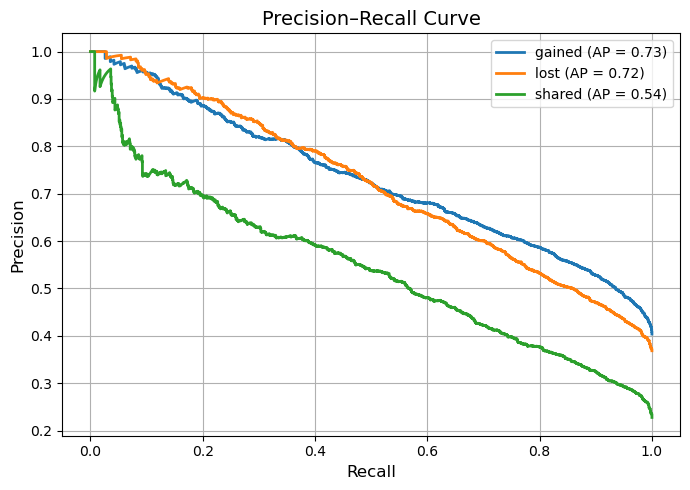

In [115]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = le.classes_  # ['gained', 'lost', 'shared']

# Plot PR curves for each class
plt.figure(figsize=(7, 5))

for i in range(3):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall, precision, lw=2, label=f"{class_names[i]} (AP = {ap:.2f})")

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision–Recall Curve", fontsize=14)
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
# second
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# === 1. Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# === 2. Replace inf ===
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

from sklearn.preprocessing import OrdinalEncoder

# Detect and encode categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

encoder = OrdinalEncoder()
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])


# === 3. Impute ===
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# === 4. Type convert ===
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# === 5. Apply multi-class SMOTE ===
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 6. Grid search ===
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',  # Use accuracy or macro F1, not AUC here
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)
model = grid.best_estimator_

# === 7. Predict ===
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# === 8. Evaluation ===
print("\nBest Parameters:", grid.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# === 9. Multi-class ROC AUC ===
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
print("Macro-average AUC (OvR):", roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'))

# === 10. Debug info ===
print("\nX_train shape:", X_train.shape)
print("NaNs:", np.isnan(X_train).sum(), "Infs:", np.isinf(X_train).sum())
print("Min:", np.nanmin(X_train), "Max:", np.nanmax(X_train))
print("y_train unique:", np.unique(y_train))


Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:17:53] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:17:55] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:17:57] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/us


Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

Classification Report:
               precision    recall  f1-score   support

  gained_0kb       0.65      0.60      0.63      2607
    lost_0kb       0.69      0.61      0.65      2942
  shared_0kb       0.31      0.48      0.38       907

    accuracy                           0.59      6456
   macro avg       0.55      0.57      0.55      6456
weighted avg       0.62      0.59      0.60      6456

Macro-average AUC (OvR): 0.7533456415907217

X_train shape: (25821, 17)
NaNs: 0 Infs: 0
Min: -3.2054796 Max: 174.04437
y_train unique: [0 1 2]


In [23]:
# third
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import numpy as np

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Handle infinite values
print("Checking for infinite values...")
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Convert to float32
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# SMOTE resampling
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# GridSearchCV for XGBoost
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)
model = grid.best_estimator_

# Predict
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Classification Report
print("\nBest Parameters:", grid.best_params_)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Macro AUC
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])
print("Macro-average AUC (OvR):", roc_auc_score(y_test_binarized, y_proba, average="macro", multi_class="ovr"))

# Per-class AUC
for i in range(3):
    auc_i = roc_auc_score(y_test_binarized[:, i], y_proba[:, i])
    print(f"{le.classes_[i]} AUC:", round(auc_i, 4))

# Debug Info
print("\nData Info:")
print("X_train_res shape:", X_train_res.shape)
print("NaNs in X_train_res:", np.isnan(X_train_res).sum())
print("Inf in X_train_res:", np.isinf(X_train_res).sum())
print("X_train_res min:", np.nanmin(X_train_res))
print("X_train_res max:", np.nanmax(X_train_res))
print("y_train_res class distribution:", np.bincount(y_train_res))


Checking for infinite values...
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:26:14] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:26:16] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [10:26:18] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/us


Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
              precision    recall  f1-score   support

  gained_0kb       0.65      0.62      0.64      2648
    lost_0kb       0.67      0.60      0.63      2886
  shared_0kb       0.32      0.46      0.38       922

    accuracy                           0.59      6456
   macro avg       0.55      0.56      0.55      6456
weighted avg       0.61      0.59      0.60      6456

Macro-average AUC (OvR): 0.7508043718861455
gained_0kb AUC: 0.7743
lost_0kb AUC: 0.7427
shared_0kb AUC: 0.7354

Data Info:
X_train_res shape: (34620, 17)
NaNs in X_train_res: 0
Inf in X_train_res: 0
X_train_res min: -3.2054796
X_train_res max: 174.04437
y_train_res class distribution: [11540 11540 11540]


In [24]:
y_pred_label = model.predict(X_test)

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_label)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1641  581  426]
 [ 664 1734  488]
 [ 209  285  428]]


NameError: name 'sns' is not defined

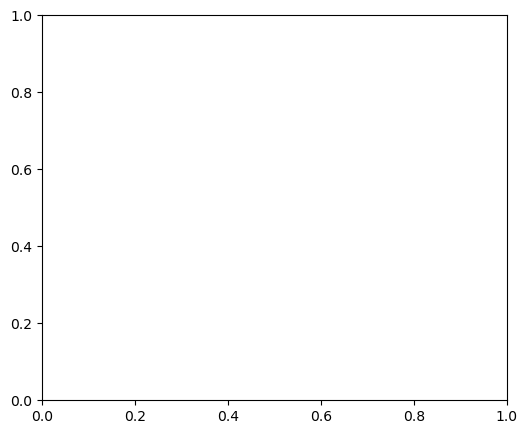

In [26]:
class_names = ['Gained', 'Lost', 'Shared']  # Update to match cm shape

df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    df_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar=True,
    square=True,
    annot_kws={"size": 12},
    ax=ax
)

ax.set_xlabel('Predicted Label', fontsize=14, labelpad=10)
ax.set_ylabel('True Label', fontsize=14, labelpad=10)
ax.set_title('Confusion Matrix', fontsize=16, pad=12)
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()


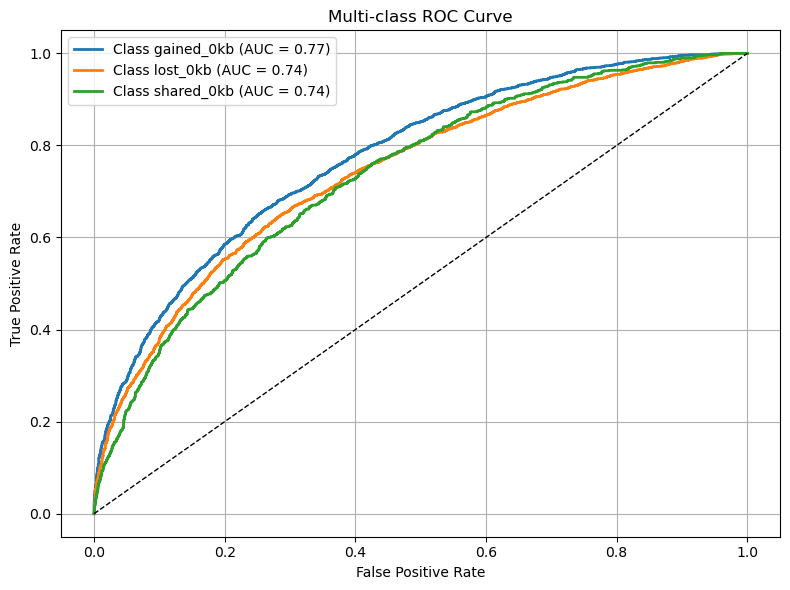

In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # 3 classes
n_classes = y_test_bin.shape[1]

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Class {le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [28]:
from xgboost import plot_importance
#plot_importance(model, importance_type='gain')

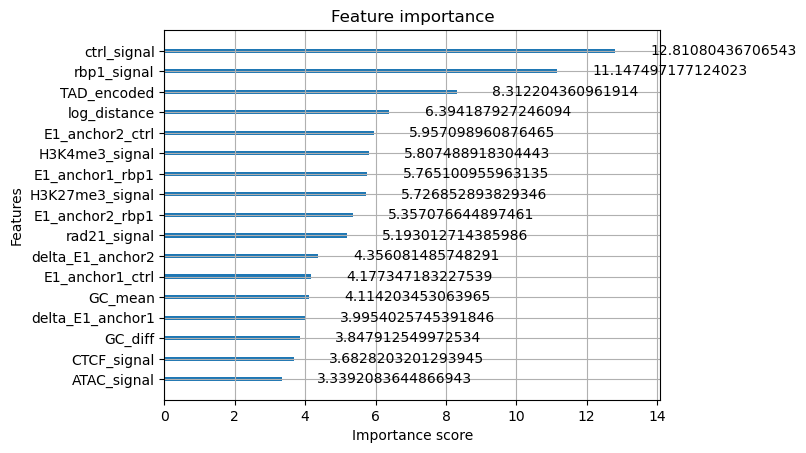

In [29]:
model.get_booster().feature_names = X.columns.tolist()
plot_importance(model, importance_type='gain', max_num_features=20)
plt.show()

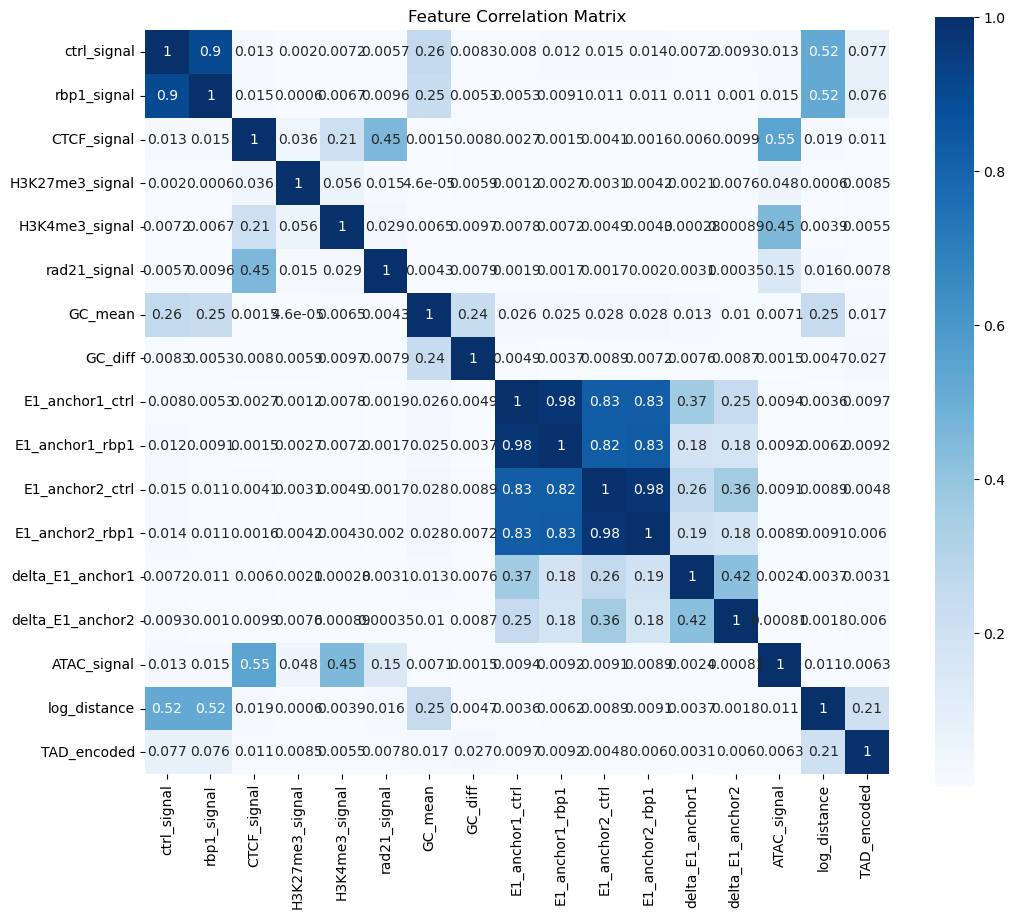

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='Blues', square=True)
plt.title("Feature Correlation Matrix")
plt.show()


In [ ]:
threshold = 0.9
high_corr = [(i, j) for i in corr.columns for j in corr.columns if i != j and corr.loc[i, j] > threshold]
set([tuple(sorted(pair)) for pair in high_corr])


{('E1_anchor1_ctrl', 'E1_anchor1_rbp1'),
 ('E1_anchor2_ctrl', 'E1_anchor2_rbp1'),
 ('ctrl_signal', 'rbp1_signal')}

In [ ]:
type(X)

pandas.core.frame.DataFrame

In [ ]:
# === 0. Select reduced features ===
selected_features = [
    'ctrl_signal',
    'rbp1_signal',
    'CTCF_signal',
    'H3K27me3_signal',
    'rad21_signal',
    'GC_mean',
    'E1_anchor2_ctrl',
    'E1_anchor1_rbp1',
    'log_distance',
    'loop_class_encoded'
]

In [ ]:
print("Selected features:", selected_features)
print("Available columns:", list(X.columns))
missing = [col for col in selected_features if col not in X.columns]
print("Missing columns:", missing)

Selected features: ['ctrl_signal', 'rbp1_signal', 'CTCF_signal', 'H3K27me3_signal', 'rad21_signal', 'GC_mean', 'E1_anchor2_ctrl', 'E1_anchor1_rbp1', 'log_distance', 'loop_class_encoded']
Available columns: ['ctrl_signal', 'rbp1_signal', 'CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean', 'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl', 'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2', 'log_distance', 'loop_class_encoded']
Missing columns: []


In [ ]:
X = X[selected_features]  # Redefine X to retain only selected features

# === 1. Imports ===
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# === 2. Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# === 3. Replace inf with NaN ===
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# === 4. Impute missing values ===
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# === 5. Type conversion ===
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# === 6. Apply SMOTE ===
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# === 7. Grid Search on XGBoost ===
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)
model = grid.best_estimator_

# === 8. Predict ===
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# === 9. Evaluate ===
print("\nBest Parameters:", grid.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# === 10. Multi-class ROC AUC ===
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
print("Macro-average AUC (OvR):", roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr'))

# === 11. Debug Info ===
print("\nX_train shape:", X_train.shape)
print("NaNs:", np.isnan(X_train).sum(), "Infs:", np.isinf(X_train).sum())
print("Min:", np.nanmin(X_train), "Max:", np.nanmax(X_train))
print("y_train unique:", np.unique(y_train))


Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:02:32] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:02:33] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:02:34] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1748293041487/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/us


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

Classification Report:
               precision    recall  f1-score   support

      gained       0.63      0.58      0.61      2607
        lost       0.63      0.57      0.60      2379
      shared       0.42      0.55      0.47      1470

    accuracy                           0.57      6456
   macro avg       0.56      0.56      0.56      6456
weighted avg       0.58      0.57      0.57      6456

Macro-average AUC (OvR): 0.7522539119042903

X_train shape: (25821, 10)
NaNs: 0 Infs: 0
Min: -2.799922 Max: 174.04437
y_train unique: [0 1 2]


In [ ]:
y_pred_label = model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_label)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1514  470  623]
 [ 530 1350  499]
 [ 351  316  803]]


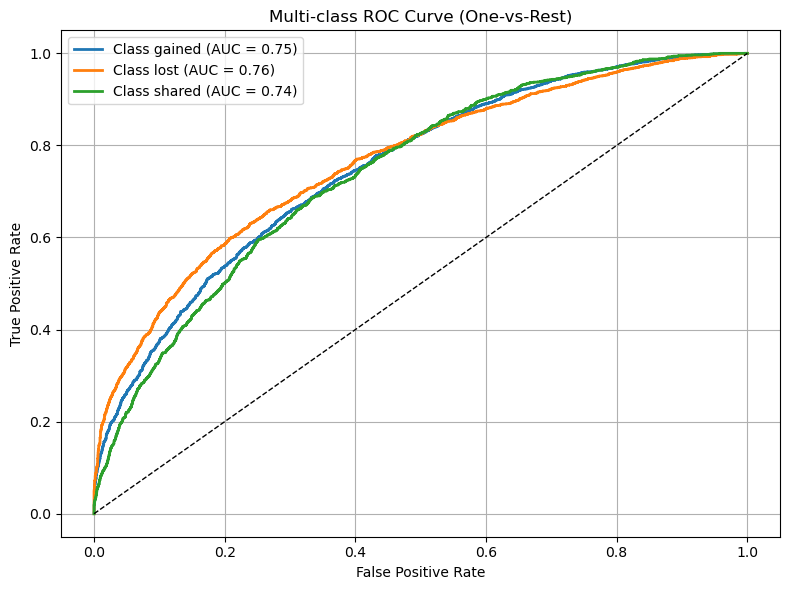

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the true labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # 3 classes
n_classes = y_test_bin.shape[1]

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Class {le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

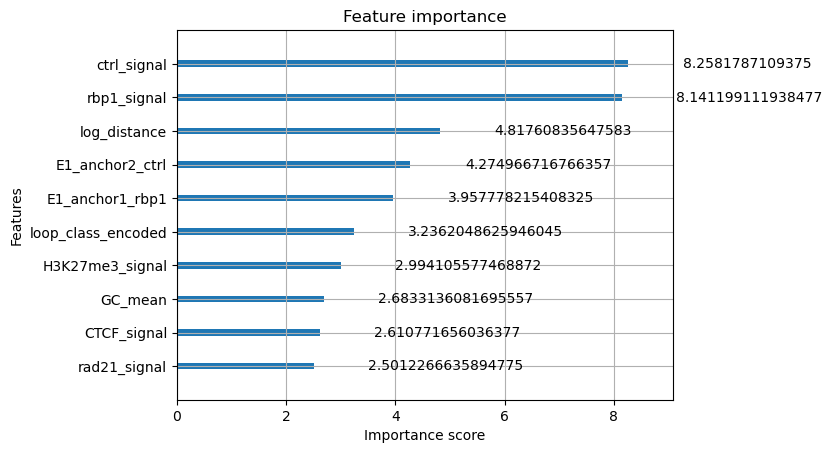

In [ ]:
model.get_booster().feature_names = X.columns.tolist()
plot_importance(model, importance_type='gain', max_num_features=20)
plt.show()

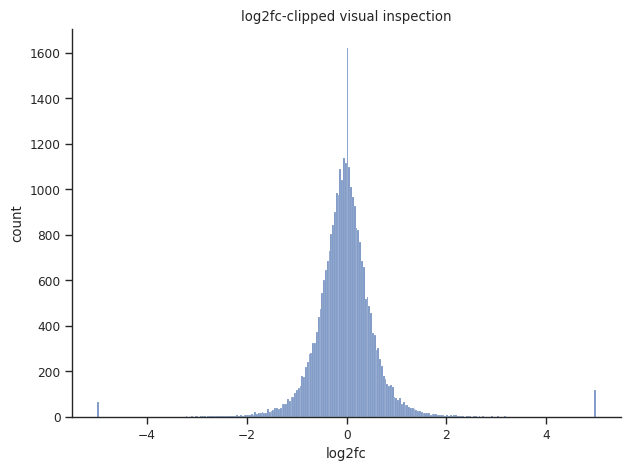

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set style/theme ONCE at the start
sns.set_theme(
    style="ticks",
    rc={"axes.spines.top": False, "axes.spines.right": False}
)
# Optional: set context for scaling (presentation/publication)
sns.set_context('paper')  # or 'talk', 'notebook', 'poster'

# 2. Create your plot (replace 'plottype' with actual type, e.g., scatterplot)
ax = sns.histplot(
    data=merged,   # DataFrame as source
    x="log2FC_clipped",     # Column for x-axis
    #y="y",     # Column for y-axis
    #hue="hue"  # Column for color groups (optional)
)
ax.set(
    title="log2fc-clipped visual inspection",
    xlabel="log2fc",
    ylabel="count"
)
plt.tight_layout()
plt.show()

In [ ]:
selected_features = [
    'ctrl_signal',
    #'rbp1_signal',
    'CTCF_signal',
    'H3K27me3_signal',
    'H3K4me3_signal',
    'rad21_signal',
    'GC_mean',
    'GC_diff',
    'E1_anchor1_ctrl',
    'E1_anchor1_rbp1',
    'E1_anchor2_ctrl',
    'E1_anchor2_rbp1',
    'delta_E1_anchor1',
    'delta_E1_anchor2',
    'distance'  # or log-transformed if skewed
]

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
RMSE: 0.6169
R^2:  0.1678


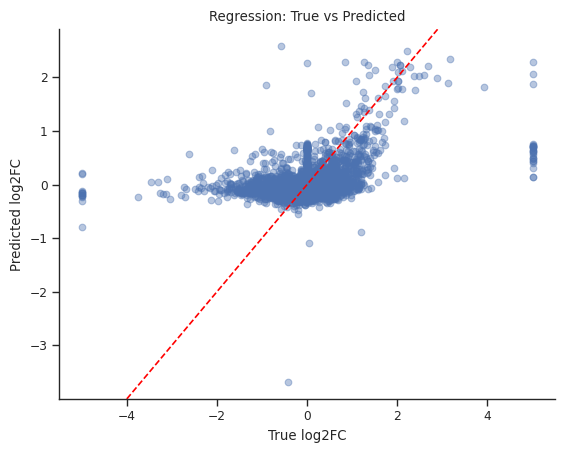

In [ ]:
### preparing for regression model

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import numpy as np
import pandas as pd

# === 0. Define features and target ===
X = merged[selected_features]  # use the same 10–16 features ## use from before
y = merged['log2FC_clipped']                 # continuous target

# === 1. Train-test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === 2. Replace inf ===
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# === 3. Encode categorical columns if any ===
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

encoder = OrdinalEncoder()
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

# === 4. Impute missing ===
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# === 5. Type conversion ===
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# === 6. Grid search ===
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        random_state=42
    ),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)
model = grid.best_estimator_

# === 7. Predict ===
y_pred = model.predict(X_test)

# === 8. Evaluation ===


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nBest Parameters:", grid.best_params_)
print(f"RMSE: {rmse:.4f}")
print(f"R^2:  {r2:.4f}")

# === 9. Optional: Plot prediction vs true ===
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("True log2FC")
plt.ylabel("Predicted log2FC")
plt.title("Regression: True vs Predicted")
plt.axline((0, 0), slope=1, color='red', linestyle='--')
plt.show()


In [ ]:
X

,ctrl_signal,CTCF_signal,H3K27me3_signal,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distance
0,NaN,3.719732,1.930504,0.188543,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN,90000
1,NaN,62.158684,1.542050,0.566125,0.063427,0.6135,0.0578,NaN,NaN,NaN,NaN,NaN,NaN,180000
2,NaN,13.704273,4.520206,0.188543,0.044699,0.6525,0.0102,NaN,NaN,NaN,NaN,NaN,NaN,140000
3,NaN,1.076765,5.414830,0.188543,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN,125000
4,NaN,16.477770,1.377250,0.188543,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN,50000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,0.006078,0.000000,0.000000,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987,345000
32273,0.007661,0.522068,0.188342,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987,310000
32274,0.001017,0.261034,0.082400,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464,430000
32275,0.004674,0.293663,0.188342,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489,230000


 97%|=================== | 6263/6456 [00:13<00:00]       

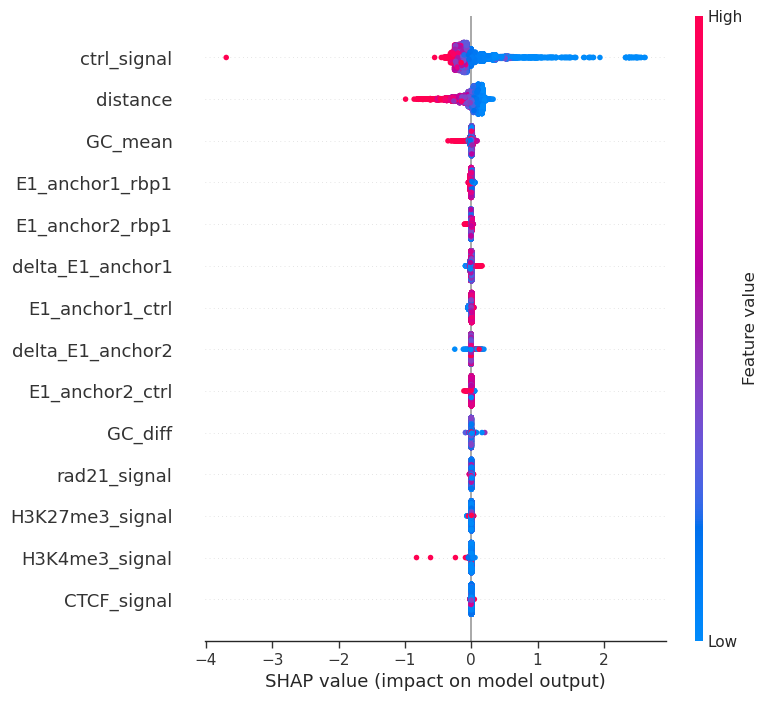

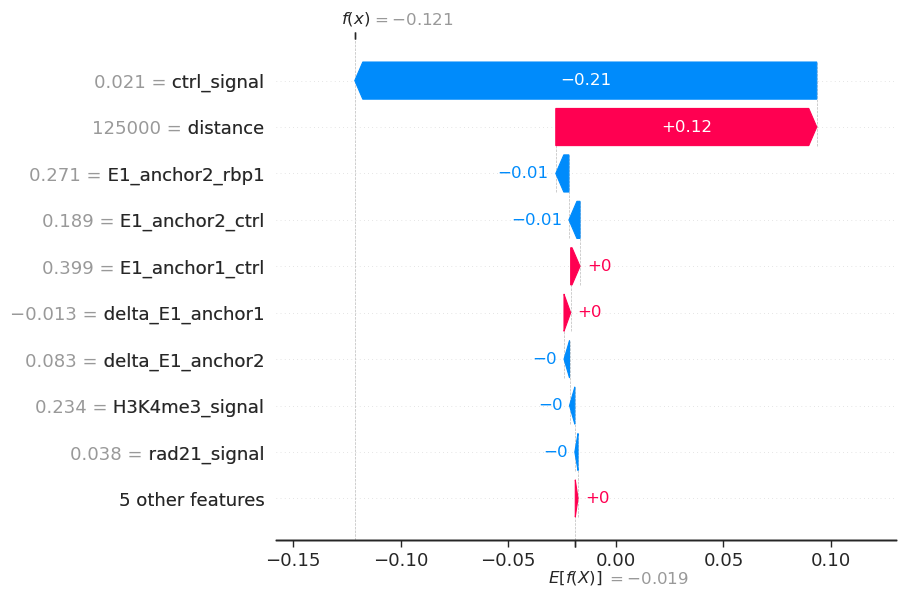

In [ ]:
import shap
import pandas as pd

# Ensure X_train and X_test are DataFrames with correct columns
X_train = pd.DataFrame(X_train, columns=selected_features)
X_test = pd.DataFrame(X_test, columns=selected_features)

# Create SHAP explainer
explainer = shap.Explainer(model, X_train)

# Compute SHAP values
shap_values = explainer(X_test)

# Global importance summary
shap.summary_plot(shap_values, X_test)  # will now show named features

# Single loop example (e.g., first loop in test set)
shap.plots.waterfall(shap_values[0])  # shows top feature contributors for one prediction

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Make sure X_test_df is a DataFrame with correct columns
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Get SHAP values per class
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_df)  # List of arrays

# Class labels (from LabelEncoder)
classes = le.classes_  # e.g., ['gained', 'lost', 'shared']

# Plot per-class SHAP summary
for i, class_name in enumerate(classes):
    print(f"SHAP summary for class: {class_name}")
    shap.summary_plot(shap_values[i], X_test_df, feature_names=X_test_df.columns.tolist(), max_display=20)


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'list' object has no attribute 'columns'

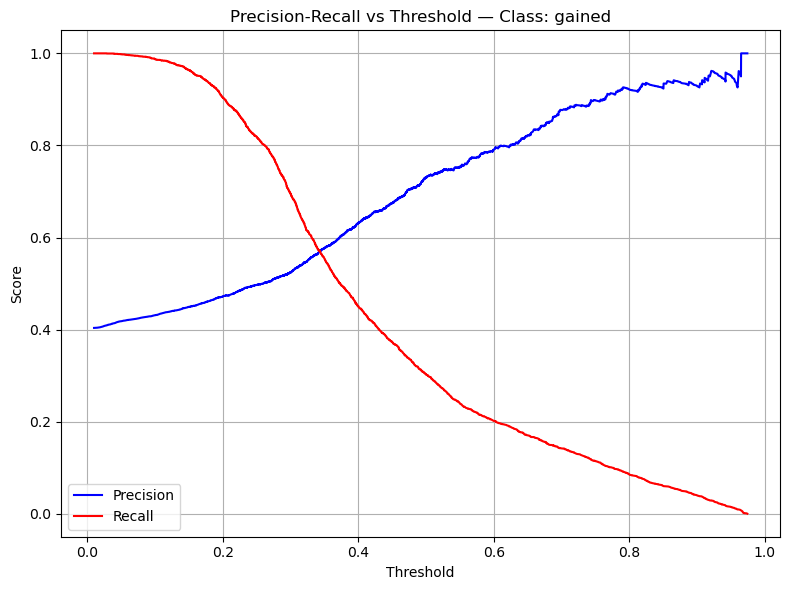

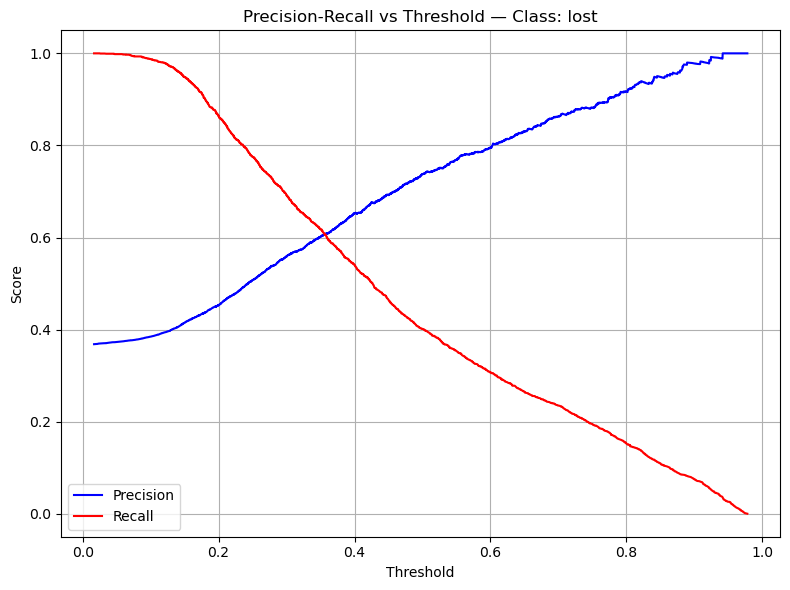

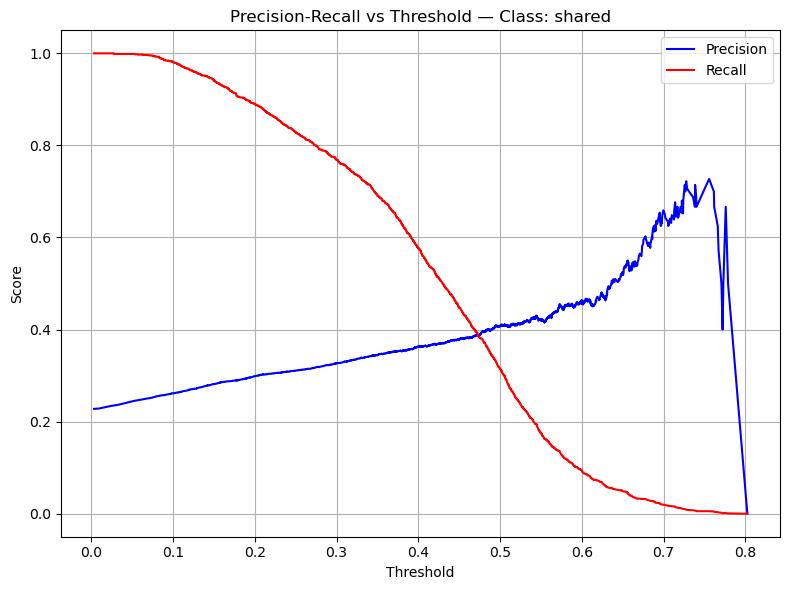

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Binarize y_test for 3-class setting
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # shape: (n_samples, 3)

# Plot precision-recall for each class
for i, class_name in enumerate(le.classes_):  # le is your LabelEncoder
    precision, recall, thresholds = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precision[:-1], label='Precision', color='b')
    plt.plot(thresholds, recall[:-1], label='Recall', color='r')
    plt.title(f'Precision-Recall vs Threshold — Class: {class_name}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Logistic regression model

In [ ]:
# split X and y into training and testing sets
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

# Encode y from strings to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # e.g. gained=0, lost=1, shared=2


X_train_lgr, X_test_lgr, y_train_lgr, y_test_lgr = train_test_split(X, y_encoded, test_size=0.25, random_state=16)

In [ ]:
### code llm - for cleanup
# Handle data types and problematic values
# First, check for and handle infinite values
print("Checking for infinite values...")
if hasattr(X_train_lgr, 'replace'):  # if pandas DataFrame
    X_train_lgr = X_train_lgr.replace([np.inf, -np.inf], np.nan)
    X_test_lgr = X_test_lgr.replace([np.inf, -np.inf], np.nan)
else:  # if numpy array
    X_train_lgr[np.isinf(X_train_lgr)] = np.nan
    X_test_lgr[np.isinf(X_test_lgr)] = np.nan

# Handle missing values (including the inf values we just converted to NaN)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train_lgr = imputer.fit_transform(X_train_lgr)
X_test_lgr = imputer.transform(X_test_lgr)

# Check for extremely large values that might cause overflow
print("Checking data ranges...")
print(f"X_train_lgr min: {np.min(X_train_lgr)}, max: {np.max(X_train_lgr)}")
print(f"X_test_lgr min: {np.min(X_test_lgr)}, max: {np.max(X_test_lgr)}")

# Convert to float32 after cleaning
X_train_lgr = X_train_lgr.astype(np.float32)
X_test_lgr = X_test_lgr.astype(np.float32)

# Convert target to integers if needed
y_train_lgr = y_train_lgr.astype(int)
y_test_lgr = y_test_lgr.astype(int)

Checking for infinite values...
Checking data ranges...
X_train_lgr min: -17.52109480589503, max: 16.791759928045582
X_test_lgr min: -16.517509535789017, max: 16.185442193508266


In [ ]:
from sklearn.linear_model import LogisticRegression

#instantiate
lgr_ins = LogisticRegression(random_state=20)

lgr_ins.fit(X_train_lgr, y_train_lgr)

y_prediction = lgr_ins.predict(X_test_lgr)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# evaluate

from sklearn import metrics
cnf = metrics.confusion_matrix(y_test_lgr, y_prediction)
cnf

array([[2516,  715,  123],
       [1136, 1612,  106],
       [1082,  599,  181]])

Text(0.5, 427.9555555555555, 'Predicted label')

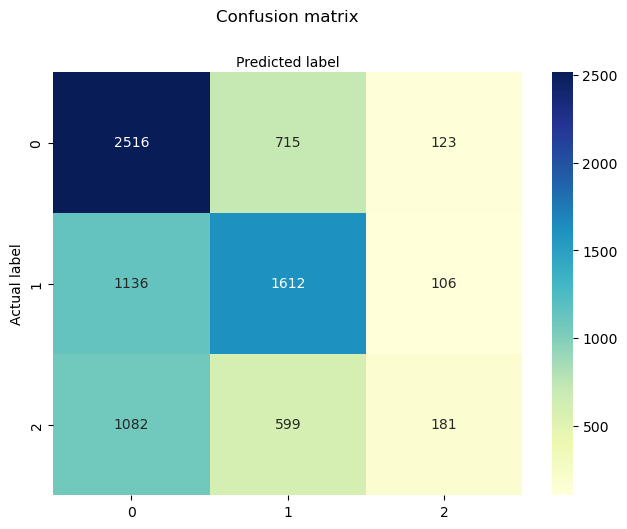

In [ ]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
from sklearn.metrics import classification_report
target_names = ['gained', 'lost', 'shared']
print(classification_report(y_test_lgr, y_prediction, target_names=target_names))

              precision    recall  f1-score   support

      gained       0.53      0.75      0.62      3354
        lost       0.55      0.56      0.56      2854
      shared       0.44      0.10      0.16      1862

    accuracy                           0.53      8070
   macro avg       0.51      0.47      0.45      8070
weighted avg       0.52      0.53      0.49      8070



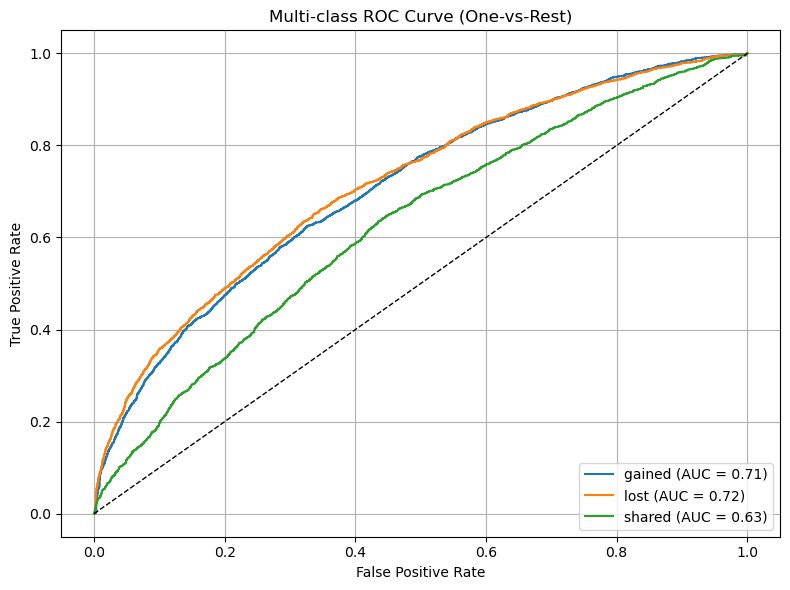

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Binarize labels: shape = (n_samples, 3)
y_test_bin = label_binarize(y_test_lgr, classes=[0, 1, 2])
class_names = le.classes_  # ['gained', 'lost', 'shared']

# Predict probabilities
y_pred_proba = lgr_ins.predict_proba(X_test_lgr)

# Plot all ROC curves
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


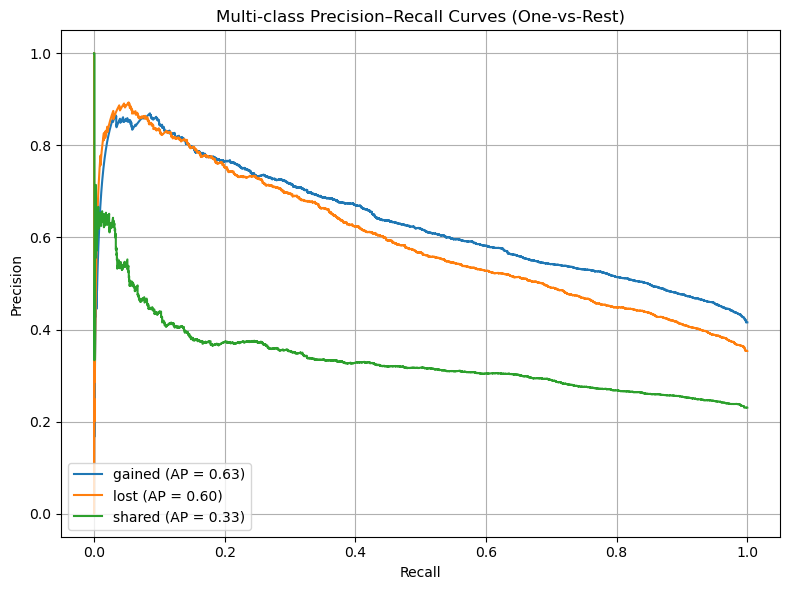

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Binarize y_test: shape = (n_samples, 3)
y_test_bin = label_binarize(y_test_lgr, classes=[0, 1, 2])
y_pred_proba_lgr = lgr_ins.predict_proba(X_test_lgr)

# Class names based on LabelEncoder
class_names = le.classes_  # e.g., ['gained', 'lost', 'shared']

# Plot PR curves for all classes
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_lgr[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred_proba_lgr[:, i])
    plt.plot(recall, precision, label=f"{class_name} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multi-class Precision–Recall Curves (One-vs-Rest)")
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# fine tuning the model

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.62      0.45      0.52      2607
           1       0.64      0.54      0.59      2379
           2       0.35      0.61      0.45      1470

    accuracy                           0.52      6456
   macro avg       0.54      0.54      0.52      6456
weighted avg       0.57      0.52      0.53      6456

